# EXERCICE 7 : REGRESSION LINEAIRE MULTIPLE AVEC REGULARISATION + VALIDATION CROISEE


Inspire de http://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_and_elasticnet.html


In [2]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


#### Génération de donnée synthétiques...

In [3]:

np.random.seed(31)

#... definition de n et p
n = [75]
p =  200   #remarque : n<200 => necessite de selectionner des variables

#... simulation de X
X=[]
for i in range(len(n)):
    X.append(np.random.randn(n[i], p)) #remarque : on ne tient pas en compte les $beta_0$

#... generation du vecteur beta dans lequel seules 10 valeurs sont non-nulles
beta = 3 * np.random.randn(p)
inds = np.arange(p)
np.random.shuffle(inds)
beta[inds[10:]] = 0 

#... simulation de y 
y=[]
X_train = []
y_train = []
X_test = []
y_test = []
for i in range(len(n)):
    y.append(np.dot(X[i], beta) + (2.0 * np.random.normal(size=n[i])))


# REMARQUE IMPORTANTE : y ne dépend que des variables i pour lesquelles beta[i] est non-nul


# ... coupe en deux les donnees en donnees d'apprentissage et donnes test
    thresh=n[i] // 2
    X_train.append(X[i][thresh:])
    y_train.append(y[i][thresh:])
    X_test.append(X[i][:thresh])
    y_test.append(y[i][:thresh])


#### Régression linéaire avec régularisation Lasso ...


In [4]:

from sklearn.linear_model import Lasso

alpha = 0.5
y_pred_lasso = []
mse_score_lasso = []
for i in range(len(n)):
    lasso_regressor = Lasso(alpha=alpha)
    lasso_regressor.fit(X_train[i], y_train[i])
    y_pred_lasso.append(lasso_regressor.predict(X_test[i]))
    mse_score_lasso.append(mean_squared_error(y_test[i], y_pred_lasso[i]))


####  Représentation du résultat


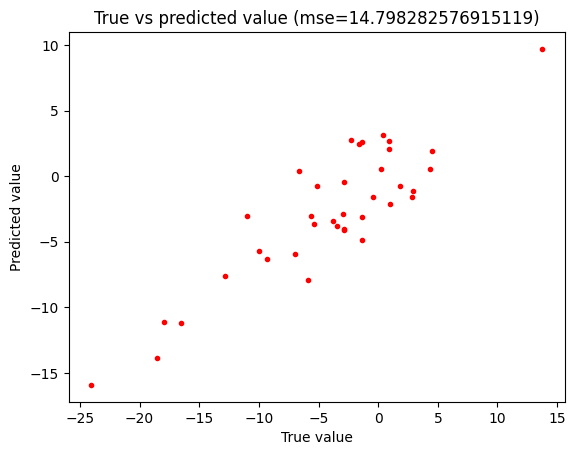

In [5]:
for i in range(len(n)):
    fig = plt.figure()
    plt.plot(y_test[i], y_pred_lasso[i], 'r.')
    plt.xlabel('True value')
    plt.ylabel('Predicted value')
    plt.title('True vs predicted value (mse='+str(mse_score_lasso[i])+')')
    plt.show()



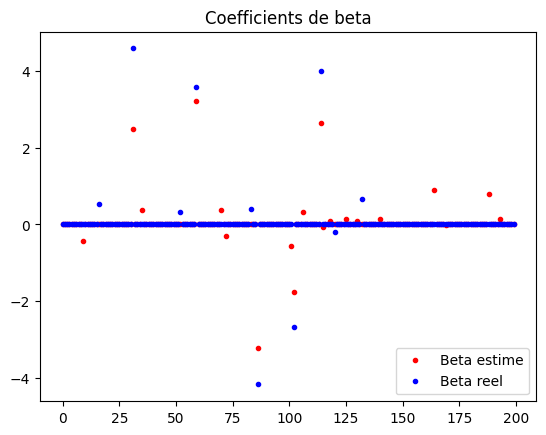

In [6]:

fig = plt.figure()
plt.plot(lasso_regressor.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()



### <span style="color:blue">QUESTION 1</span> :

Jouez l'exemple avec  n=1000, n=100, n=75, n=50, n=25. Qu'en deduisez vous sur l'impact du nombre d'observations

### <span style="color:blue">REPONSE 1</span> :

le nombre d'observation a un fort impact sur la mse : visiblement plus il augmente, plus la mse est faible.



### <span style="color:blue">QUESTION 2</span> :

On garde n=75. Utilisez la validation croisee de type K-folds (typiquement 8-Folds) pour trouver le meilleur coefficient *alpha* au sens de la MSE. Pour chaque *alpha* testé, on gardera comme score la MSE moyenne obtenue sur tous les *folds*.

Remarque : la recherche d'un bon coefficient *alpha* pourra d'abord se faire sur une échelle exponentielle assez large (ex: 0.001, 0.01, 0.1, ...) puis être raffinée sur une échelle plus fine.  

### <span style="color:blue">REPONSE 2</span> :

MSE moyen par alpha :
alpha=0.0001: MSE=93.6109
alpha=0.001: MSE=12.2064
alpha=0.01: MSE=10.7570
alpha=0.05: MSE=9.6307
alpha=0.1: MSE=8.8469
alpha=0.3: MSE=7.8861
alpha=0.5: MSE=8.5450
alpha=0.6: MSE=9.1191
alpha=1: MSE=12.3548
alpha=5: MSE=71.3591
alpha=10: MSE=71.3591

Meilleur alpha = 0.3 avec MSE moyen = 7.8861


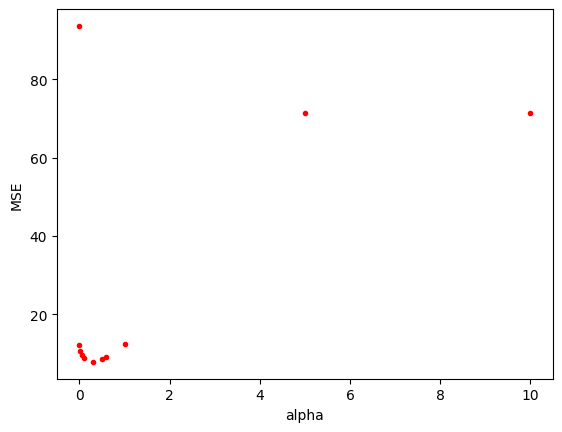

In [31]:

from sklearn.model_selection import KFold

np.random.seed(31)

#... definition de n et p
n = [75]
p =  200   #remarque : n<200 => necessite de selectionner des variables

#... simulation de X
X=[]
for i in range(len(n)):
    X.append(np.random.randn(n[i], p)) #remarque : on ne tient pas en compte les $beta_0$

#... generation du vecteur beta dans lequel seules 10 valeurs sont non-nulles
beta = 3 * np.random.randn(p)
inds = np.arange(p)
np.random.shuffle(inds)
beta[inds[10:]] = 0 

#... simulation de y 
y=[]
for i in range(len(n)):
    y.append(np.dot(X[i], beta) + (2.0 * np.random.normal(size=n[i])))

# REMARQUE IMPORTANTE : y ne dépend que des variables i pour lesquelles beta[i] est non-nul

# Conversion en array numpy (pour KFold)
X = np.array(X[0])
y = np.array(y[0])

# --- KFold ---
kf = KFold(n_splits=5, shuffle=True, random_state=31)

alpha_values = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.6, 1, 5, 10]

results = {}

for alpha in alpha_values:
    mse_scores = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Lasso regression
        lasso_regressor = Lasso(alpha=alpha, max_iter=10000)
        lasso_regressor.fit(X_train, y_train)
        y_pred = lasso_regressor.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mse_scores.append(mse)
    
    # Stockage du résultat moyen pour cet alpha
    results[alpha] = np.mean(mse_scores)

# Affichage des résultats
mse_plot = []
print("MSE moyen par alpha :")
for alpha, mse in results.items():
    print(f"alpha={alpha}: MSE={mse:.4f}")
    mse_plot.append(mse)

# Meilleur alpha
best_alpha = min(results, key=results.get)
print(f"\nMeilleur alpha = {best_alpha} avec MSE moyen = {results[best_alpha]:.4f}")

#pour alpha = 0.3 on a une valeur de la mse minimale
plt.plot(alpha_values, mse_plot, 'r.')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.show()


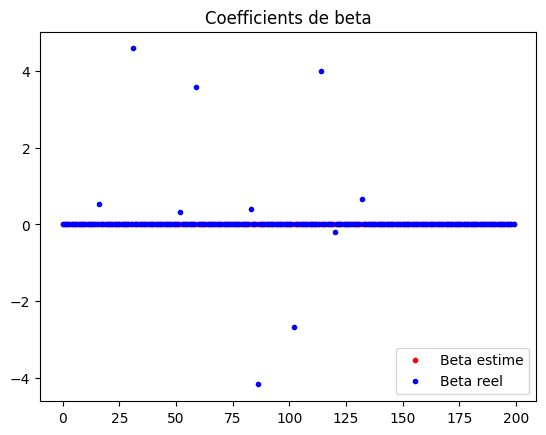

In [17]:
#représentation des coefficients estimés (lasso_regressor.coef_) et de ceux
#avec lesquels les données ont été simulées (beta)

fig = plt.figure()
plt.plot(lasso_regressor.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()


### <span style="color:blue">QUESTION 3</span> :

De manère alternative, codez et testez maintenant une sélection de type *forward* avec un critère de sélection *BIC*.

Comparez les résultats avec ceux obtenus à l'aide de la pénalisation LASSO.

### <span style="color:blue">REPONSE 3</span> :


In [27]:


from sklearn.linear_model import LinearRegression


np.random.seed(31)

#... definition de n et p
n = 75
p =  200   #remarque : n<200 => necessite de selectionner des variables

#... simulation de X


X = (np.random.randn(n, p)) #remarque : on ne tient pas en compte les $beta_0$

#... generation du vecteur beta dans lequel seules 10 valeurs sont non-nulles
beta = 3 * np.random.randn(p)
inds = np.arange(p)
np.random.shuffle(inds)
beta[inds[10:]] = 0 

#... simulation de y 

y=(np.dot(X[i], beta) + (2.0 * np.random.normal(size=n)))

def forward_selection(X_train, y_train, X_test, y_test, max_features):
    n, p = X_train.shape
    selected_features = [] #selection de variables 1 par 1
    remaining_features = list(range(p)) #variables restantes après chaque séléction
    current_score = float('inf')
    
    for _ in range(max_features):
        best_feature = None #meilleure variable à ajouter
        best_score = current_score #critère de performance (MSE)
        
        for feature in remaining_features:
            features_to_test = selected_features + [feature] #variables à tester : variables deja sélectionnées + nouvelle variable
            X_subset = X_train[:, features_to_test] #sous-matrice de X avec les variables sélectionnées
            model = LinearRegression().fit(X_subset, y_train)
            y_pred = model.predict(X_test[:, features_to_test])
            score = n*np.log(mean_squared_error(y_test, y_pred)) + np.log(n)*(len(features_to_test)+1) #critère de performance BIC
            
            if score < best_score:
                best_score = score #mise à jour du meilleur score si la nouvelle variable améliore le modèle
                best_feature = feature #mise à jour de la meilleure variable si la nouvelle variable améliore le modèle
        
        if best_feature is not None:
            selected_features.append(best_feature) #ajout de la meilleure variable à la liste des variables sélectionnées si elle améliore le modèle
            remaining_features.remove(best_feature)
            current_score = best_score
        else:
            break #arrêt si aucune amélioration n'est possible
    
    return selected_features
sum_mse_scores=0
max_features = 10
NB_folds=8
# --- KFold ---
kf = KFold(n_splits=NB_folds, shuffle=True, random_state=31)
for train, test in kf.split(X):
    print('Fold')
    X_train=X[train]
    y_train=y[train]
    X_test=X[test]
    y_test=y[test]
    selected_features = forward_selection(X_train, y_train, X_test, y_test, max_features)

    lr_bic = LinearRegression()
    lr_bic.fit(X_train[:, selected_features], y_train)
    y_p_bic = lr_bic.predict(X_test[:, selected_features])
    
    mse_bic = mean_squared_error(y_p_bic, y_test)
    
    sum_mse_scores+=mse_bic
    print("Variables sélectionnées :", selected_features)


Fold
Variables sélectionnées : [152, 72, 9, 20, 105, 194, 23, 63, 36, 92]
Fold
Variables sélectionnées : [169, 185, 175, 112, 142, 58, 164, 125, 7, 38]
Fold
Variables sélectionnées : [84, 125, 134, 58, 135, 18, 112, 190, 126, 175]
Fold
Variables sélectionnées : [32, 184, 165, 72, 167, 141, 54, 0, 166, 197]
Fold
Variables sélectionnées : [134, 9, 171, 61, 56, 164, 160, 142, 102, 136]
Fold
Variables sélectionnées : [101, 13, 184, 124, 9, 116, 170, 164, 196, 136]
Fold
Variables sélectionnées : [101, 70, 15, 105, 150, 32, 35, 34, 52, 38]
Fold
Variables sélectionnées : [105, 137, 95, 20, 125, 168, 167, 88, 104, 54]


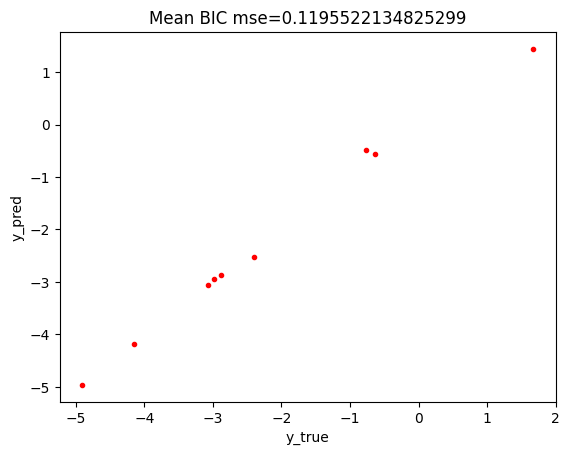

In [28]:
#show the results
plt.figure()
plt.plot(y_test, y_p_bic, 'r.')
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.title("Mean BIC mse="+str(sum_mse_scores/NB_folds))
plt.show()